<a href="https://colab.research.google.com/github/Borracheira/gravitacional-wave/blob/main/PSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PSD (Power Spectral Density)**

A PSD (Power Spectral Density), ou Densidade Espectral de Potência, descreve como a potência de um sinal ou do ruído está distribuída em função da frequência. Na análise de ondas gravitacionais, a PSD é amplamente utilizada para caracterizar o ruído dos detectores interferométricos, permitindo identificar as faixas de frequência em que o instrumento apresenta maior ou menor sensibilidade. Essa informação é fundamental para distinguir sinais astrofísicos do ruído de fundo e para otimizar técnicas de detecção, como o matched filtering, que depende de uma estimativa precisa da PSD para maximizar a razão sinal-ruído. Além disso, a análise da PSD auxilia na identificação de fontes de ruído instrumental e ambiental, contribuindo para o aprimoramento do desempenho dos detectores e para a confiabilidade das detecções de ondas gravitacionais.

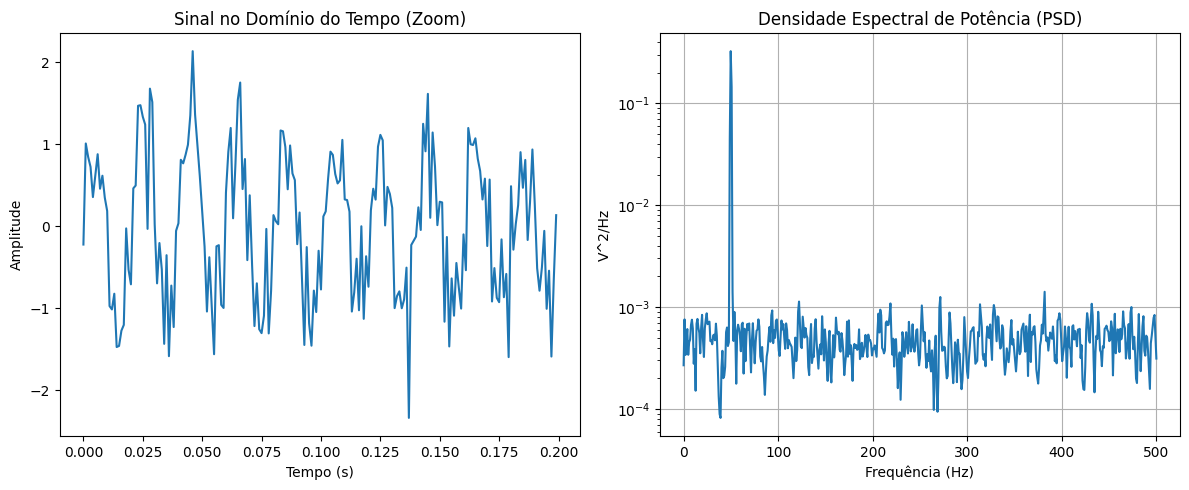

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# 1. Parâmetros do sinal
Fs_psd = 1000  # Frequência de amostragem (Hz)
T_psd = 4       # Duração (s)
t_psd = np.linspace(0, T_psd, int(Fs_psd * T_psd), endpoint=False)

# 2. Criar um sinal: Senoide de 50Hz + Ruído Branco
f_sinal = 50
sinal = np.sin(2 * np.pi * f_sinal * t_psd)
ruido = 0.5 * np.random.randn(len(t_psd))
y_psd = sinal + ruido

# 3. Calcular a PSD usando o método de Welch
frequencias, psd_valores = welch(y_psd, Fs_psd, nperseg=1024)

# 4. Plotagem
plt.figure(figsize=(12, 5))

# Sinal no tempo
plt.subplot(1, 2, 1)
plt.plot(t_psd[:200], y_psd[:200])
plt.title('Sinal no Domínio do Tempo (Zoom)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')

# PSD
plt.subplot(1, 2, 2)
plt.semilogy(frequencias, psd_valores)
plt.title('Densidade Espectral de Potência (PSD)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('V^2/Hz')
plt.grid(True)

plt.tight_layout()
plt.show()